# Fairtrack: Insect Monitoring with the FAIR-Device
<img src="https://raw.githubusercontent.com/jach999/fairtrack/main/assets/fair-d_scheme.png" width="500">

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Mar 18 16:42:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Copy repository and install dependencies

In [2]:
!git clone https://github.com/jach999/fairtrack.git
%cd fairtrack
!mkdir runs

Cloning into 'fairtrack'...
remote: Enumerating objects: 374, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 374 (delta 59), reused 51 (delta 31), pack-reused 283 (from 4)
Receiving objects: 100% (374/374), 368.90 MiB | 25.74 MiB/s, done.
Resolving deltas: 100% (157/157), done.
Updating files: 100% (62/62), done.
/content/fairtrack


In [15]:
%cd /content/fairtrack
!pip install -r requirements.txt

[Errno 2] No such file or directory: 'fairtrack'
/content/fairtrack
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.3/901.3 kB 25.3 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.53
    Uninstalling ultralytics-8.0.53:
      Successfully uninstalled ultralytics-8.0.53


Continue here with the installation of ByteTrack

In [12]:
%cd /content/fairtrack
!python install_bytetrack.py

/content/fairtrack
fatal: destination path 'ByteTrack' already exists and is not an empty directory.

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -o
ERROR: Could not find a version that satisfies the requirement sssssssssssssssssssssssssssssssssssssh5py (from versions: none)
ERROR: No matching distribution found for sssssssssssssssssssssssssssssssssssssh5py
yolox.__version__: 0.1.0
ByteTrack installation completed successfully!


Correct deprecated numpy variables

In [28]:
%cd /content/fairtrack/utils
!python correct_np_variables.py
!python correct_np_supervision_variables.py

/content/fairtrack/utils
Modification completed successfully for /content/fairtrack/ByteTrack/yolox/tracker/byte_tracker.py
Modification completed successfully for /content/fairtrack/ByteTrack/yolox/tracker/matching.py
All modifications completed successfully.
Replacements made successfully in /usr/local/lib/python3.11/dist-packages/supervision/detection/core.py
All modifications completed successfully.


## Test the script

Let's start to process an image

/content/fairtrack
test_assets/images/7.jpg runs/7_test.jpg
/content/fairtrack
Model summary (fused): 168 layers, 11,140,677 parameters, 0 gradients, 28.5 GFLOPs

0: 480x640 1 hoverfly, 63.5ms
Speed: 4.8ms preprocess, 63.5ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)
hoverfly #1 detected in Inside polygon
Data written to /content/fairtrack/runs
Image shape: (600, 800, 3)


(-0.5, 799.5, 599.5, -0.5)

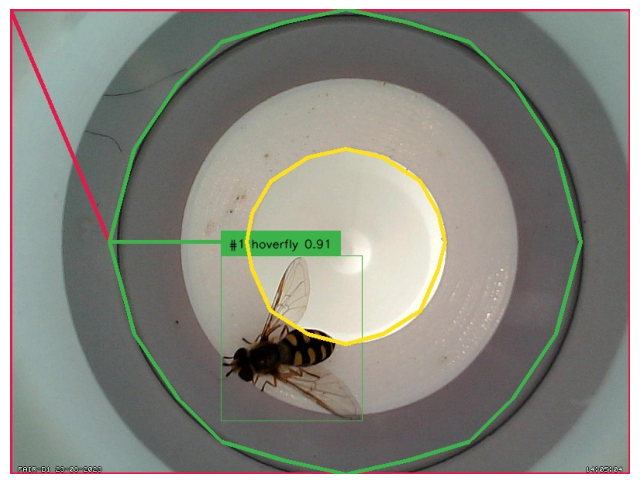

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

%cd /content/fairtrack

# Define source and target image paths
source_img_path = "test_assets/images/7.jpg"
source_img_filename = os.path.basename(source_img_path)
source_file_name, _ = os.path.splitext(source_img_filename)
target_img_path = os.path.join("runs", f"{source_file_name}_test.jpg")
print(source_img_path, target_img_path)

# Other options
device_type = "fd1"
model_type = "39_class"

# Run the script
!python fairtrack_test_image.py $source_img_path $target_img_path --device $device_type --model $model_type

# Load the processed image
img = cv2.imread(target_img_path)
print(f"Image shape: {img.shape}")
# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
plt.axis('off')  # Hide axes

Now, let's try with a whole video

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import moviepy.editor

# Define source and target video paths
source_vid_path = "test_assets/fdV2_5/fd1/11-17-18.mp4"
source_vid_filename = os.path.basename(source_vid_path)
source_file_name, _ = os.path.splitext(source_vid_filename)
target_vid_path = os.path.join("runs", f"{source_file_name}_test.mp4")
print(source_vid_path, target_vid_path)

# Other options
device_type = "fd1"
model_type = "39_class"
detection_confidence = 0.6

# Run the script
!python fairtrack_test_video.py $source_vid_path $target_vid_path --device $device_type --model $model_type --conf $detection_confidence

from IPython import display
display.clear_output()

print(f"Data written to {os.path.dirname(target_vid_path)}")